# IPL Score Prediction

Predicting the final first-innings total of an IPL match from the in-progress
match state (teams, venue, players, runs/wickets/overs so far) using a small
feed-forward neural network built with Keras/TensorFlow.

**Pipeline:** load data → explore → encode categoricals → scale → train a
dense regression network → evaluate → interactive "live" score predictor.


In [21]:
# --- Core libraries ---
import numpy as np
import pandas as pd

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# --- ML utilities ---
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- Deep learning ---
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping

RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)


## 1. Load the dataset

In [22]:
match_df = pd.read_csv("ipl_data.csv")
match_df.dropna(inplace=True) # Remove rows with any NaN values
print(f"Rows: {match_df.shape[0]:,}  |  Columns: {match_df.shape[1]}")
match_df.sample(8, random_state=RANDOM_SEED)

Rows: 76,014  |  Columns: 15


,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
52744,428,2014-05-14,Barabati Stadium,Mumbai Indians,Kolkata Knight Riders,RG Sharma,M Morkel,115,3,15.5,51,1,37,18,141
71456,580,2017-04-19,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,Delhi Daredevils,KS Williamson,AD Mathews,148,1,15.6,56,0,89,51,191
61442,500,2015-05-19,Wankhede Stadium,Mumbai Indians,Chennai Super Kings,PA Patel,R Ashwin,1,0,0.3,1,0,1,0,187
66000,536,2016-05-06,"Rajiv Gandhi International Stadium, Uppal",Gujarat Lions,Sunrisers Hyderabad,AJ Finch,Mustafizur Rahman,97,5,16.4,29,1,35,11,126
3497,29,2008-05-08,Eden Gardens,Kolkata Knight Riders,Royal Challengers Bangalore,DJ Hussey,A Kumble,64,4,8.6,39,2,26,3,129
75584,614,2017-05-14,Feroz Shah Kotla,Royal Challengers Bangalore,Delhi Daredevils,V Kohli,CJ Anderson,68,1,10.3,33,0,37,27,161
59243,481,2015-05-03,"Punjab Cricket Association Stadium, Mohali",Mumbai Indians,Kings XI Punjab,LMP Simmons,AR Patel,134,1,15.5,32,1,63,9,172
20822,168,2010-04-22,Dr DY Patil Sports Academy,Chennai Super Kings,Deccan Chargers,S Anirudha,RP Singh,124,6,18.5,38,2,16,1,142


In [23]:
match_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76014 entries, 0 to 76013
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   mid             76014 non-null  int64  
 1   date            76014 non-null  object 
 2   venue           76014 non-null  object 
 3   bat_team        76014 non-null  object 
 4   bowl_team       76014 non-null  object 
 5   batsman         76014 non-null  object 
 6   bowler          76014 non-null  object 
 7   runs            76014 non-null  int64  
 8   wickets         76014 non-null  int64  
 9   overs           76014 non-null  float64
 10  runs_last_5     76014 non-null  int64  
 11  wickets_last_5  76014 non-null  int64  
 12  striker         76014 non-null  int64  
 13  non-striker     76014 non-null  int64  
 14  total           76014 non-null  int64  
dtypes: float64(1), int64(8), object(6)
memory usage: 8.7+ MB


## 2. Exploratory data analysis

A quick look at how matches, teams and totals are distributed before doing
any modelling.

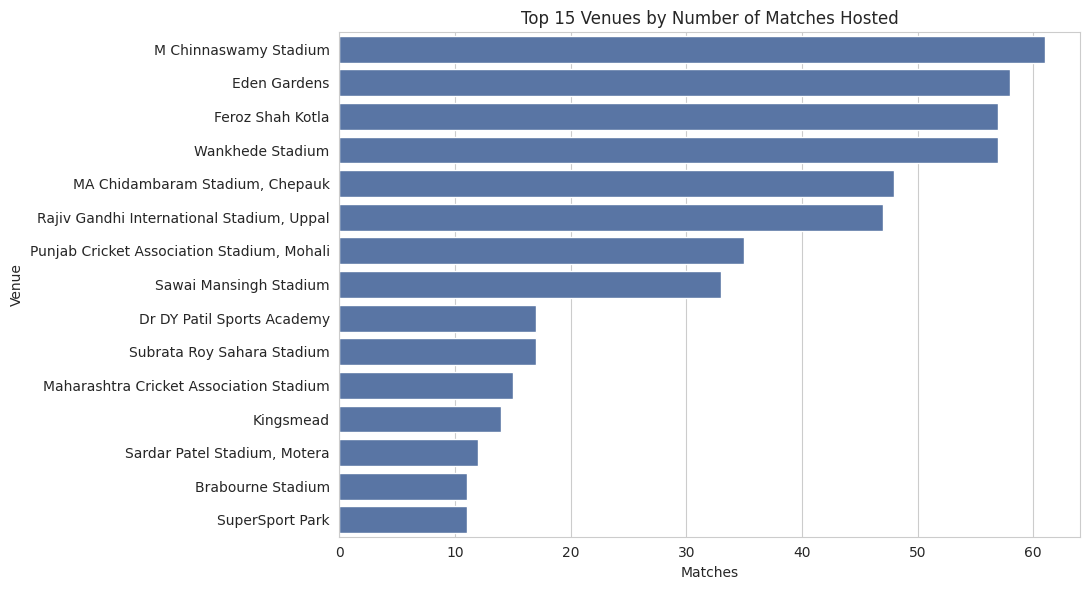

Total distinct matches in the dataset: 617


In [24]:
# How many distinct matches are recorded per venue?
venue_matches = match_df[["mid", "venue"]].drop_duplicates()
venue_counts = venue_matches["venue"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(x=venue_counts.values, y=venue_counts.index, color="#4C72B0", ax=ax)
ax.set_title("Top 15 Venues by Number of Matches Hosted")
ax.set_xlabel("Matches")
ax.set_ylabel("Venue")
plt.tight_layout()
plt.show()

print(f"Total distinct matches in the dataset: {venue_matches['mid'].nunique()}")


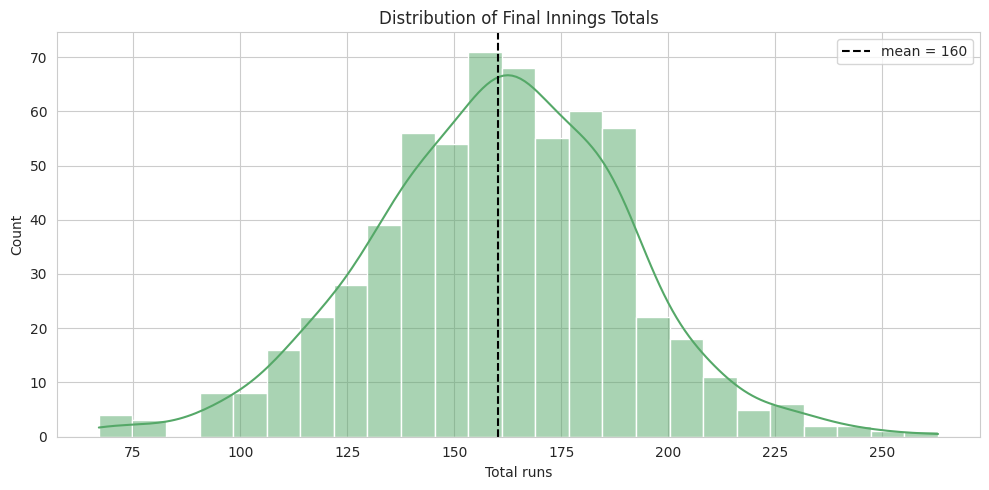

In [25]:
# Distribution of the final innings total (the modelling target)
final_totals = match_df.groupby("mid")["total"].max()

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(final_totals, bins=25, kde=True, color="#55A868", ax=ax)
ax.axvline(final_totals.mean(), color="black", linestyle="--", label=f"mean = {final_totals.mean():.0f}")
ax.set_title("Distribution of Final Innings Totals")
ax.set_xlabel("Total runs")
ax.legend()
plt.tight_layout()
plt.show()


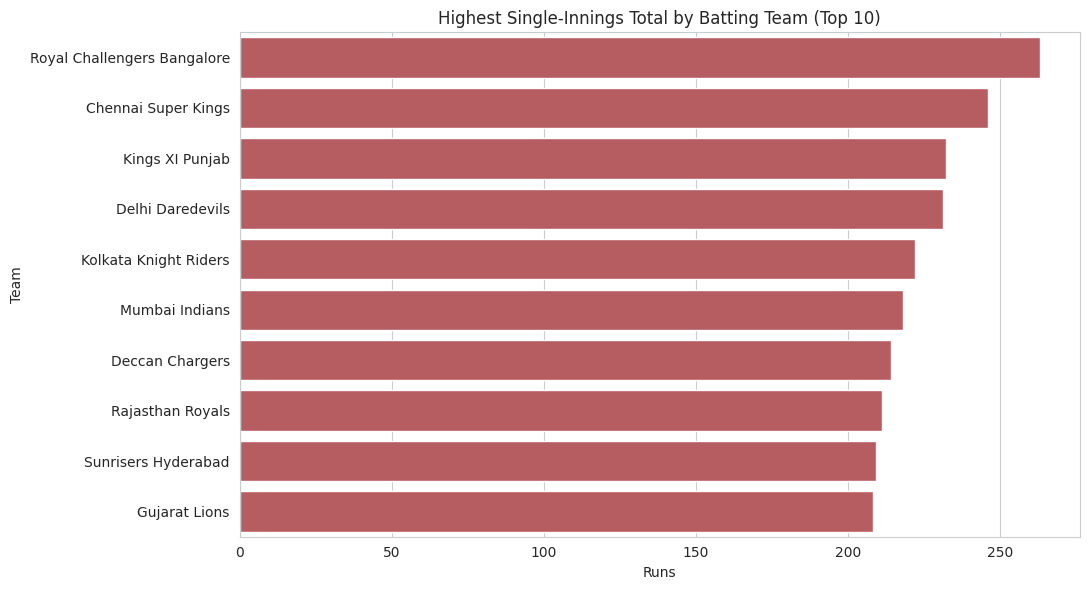

In [26]:
# Which batting sides tend to post the highest innings totals?
team_totals = match_df.groupby("bat_team")["total"].max().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(x=team_totals.values, y=team_totals.index, color="#C44E52", ax=ax)
ax.set_title("Highest Single-Innings Total by Batting Team (Top 10)")
ax.set_xlabel("Runs")
ax.set_ylabel("Team")
plt.tight_layout()
plt.show()


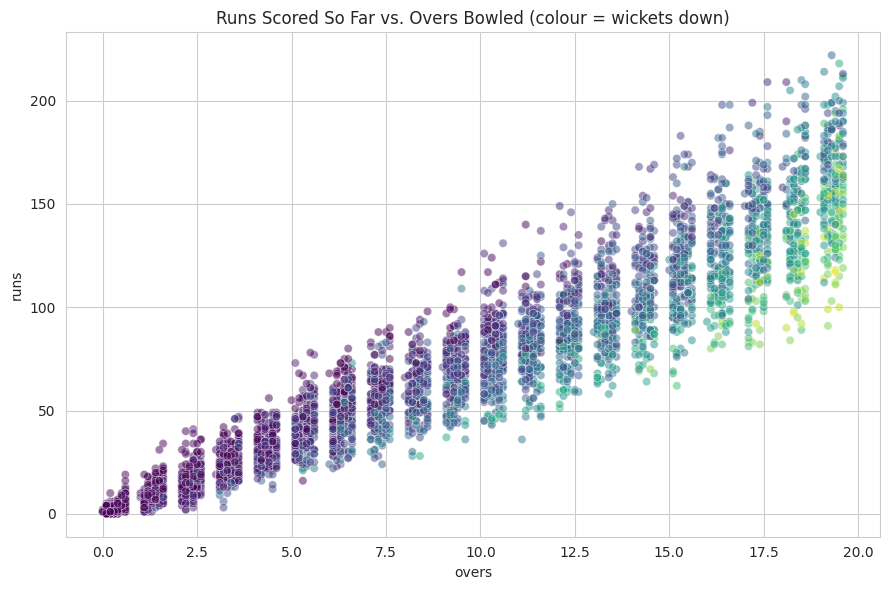

In [27]:
# Runs scored vs. overs bowled - is the relationship roughly linear or does
# scoring accelerate in the death overs?
sample = match_df.sample(min(4000, len(match_df)), random_state=RANDOM_SEED)

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=sample, x="overs", y="runs", hue="wickets", palette="viridis",
                 alpha=0.5, ax=ax, legend=False)
ax.set_title("Runs Scored So Far vs. Overs Bowled (colour = wickets down)")
plt.tight_layout()
plt.show()


## 3. Encode categorical features

Team names, venues and player names are text — a neural network needs numeric
input, so each categorical column gets its own `LabelEncoder`. The encoders
are kept around so the interactive predictor at the end can reuse the exact
same mapping.

In [28]:
CATEGORICAL_COLUMNS = ["bat_team", "bowl_team", "venue", "batsman", "bowler"]

encoded_df = match_df.copy()
encoders = {}

for column in CATEGORICAL_COLUMNS:
    encoder = LabelEncoder()
    encoded_df[column] = encoder.fit_transform(encoded_df[column])
    encoders[column] = encoder

# Explicitly drop all rows with any NaN values from the encoded DataFrame.
# This ensures that both numerical and categorical features are clean
# before creating X and y.
encoded_df.dropna(inplace=True)
encoded_df.reset_index(drop=True, inplace=True) # Reset index after dropping rows

encoded_df[CATEGORICAL_COLUMNS].head()

,bat_team,bowl_team,venue,batsman,bowler
0,6,12,14,328,201
1,6,12,14,61,201
2,6,12,14,61,201
3,6,12,14,61,201
4,6,12,14,61,201


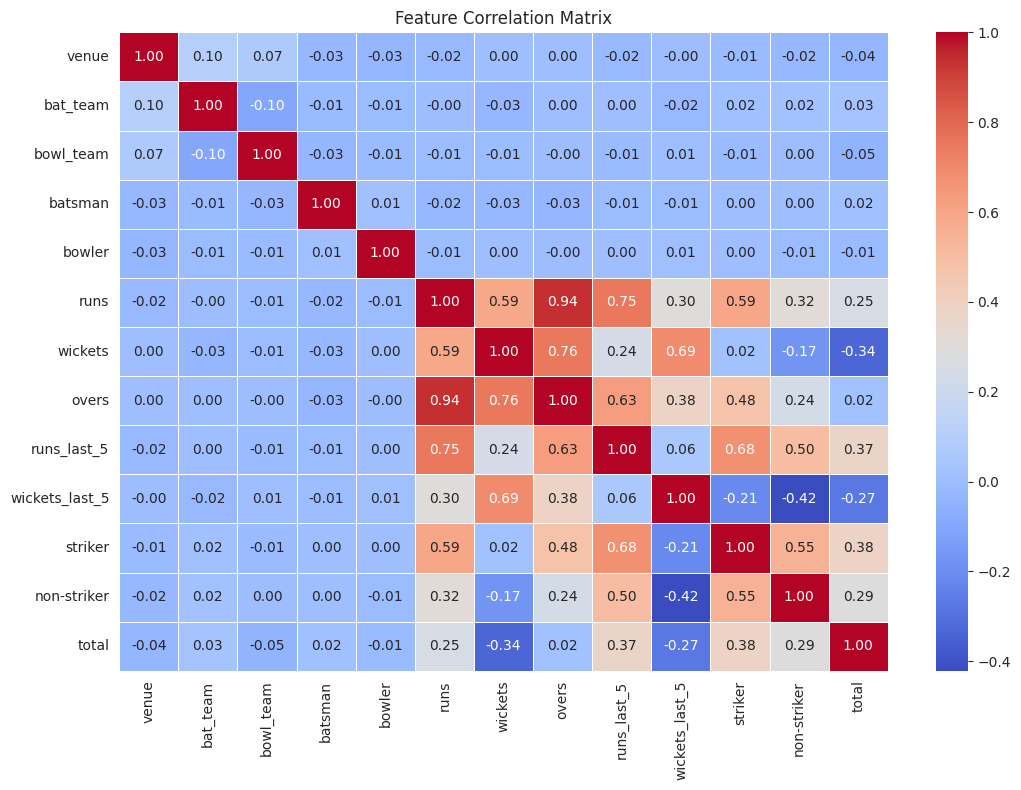

In [29]:
# Correlation between the numeric match-state features and the target
corr_features = encoded_df.drop(columns=["date", "mid"])

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr_features.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, ax=ax)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


## 4. Build the modelling table

In [30]:
FEATURE_COLUMNS = [
    "bat_team", "bowl_team", "venue",
    "runs", "wickets", "overs", "striker",
    "batsman", "bowler",
]
TARGET_COLUMN = "total"

# Ensure no NaNs in the target column before splitting features and target
# This addresses the observed NaN in the 'total' column that propagates to y.
processed_df = encoded_df.dropna(subset=[TARGET_COLUMN]).reset_index(drop=True)

X = processed_df[FEATURE_COLUMNS]
y = processed_df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)

print(f"Train rows: {len(X_train):,}  |  Test rows: {len(X_test):,}")

Train rows: 60,811  |  Test rows: 15,203


In [31]:
feature_scaler = MinMaxScaler()
X_train_scaled = feature_scaler.fit_transform(X_train)
X_test_scaled = feature_scaler.transform(X_test)


## 5. Define and train the regression network

A compact fully-connected network with dropout for a bit of regularisation.
Training uses the Huber loss (robust to the occasional very high-scoring
outlier innings) and stops early once validation loss plateaus.

In [32]:
def build_score_predictor(input_dim: int) -> keras.Model:
    net = keras.Sequential([
        keras.layers.Input(shape=(input_dim,)),
        keras.layers.Dense(256, activation="relu"),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dropout(0.1),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(1, activation="linear"),
    ])
    net.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.Huber(delta=1.0),
        metrics=["mae"],
    )
    return net

score_model = build_score_predictor(X_train_scaled.shape[1])
score_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,777 (171.00 KB)

 Trainable params: 43,777 (171.00 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
early_stop = EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

history = score_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=40,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1,
)


Epoch 1/40
951/951 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 25.7796 - mae: 26.2740 - val_loss: 15.0624 - val_mae: 15.5540
Epoch 2/40
951/951 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 16.4475 - mae: 16.9406 - val_loss: 14.9239 - val_mae: 15.4162
Epoch 3/40
951/951 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 16.1725 - mae: 16.6653 - val_loss: 14.4007 - val_mae: 14.8925
Epoch 4/40
951/951 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 16.0013 - mae: 16.4942 - val_loss: 14.5041 - val_mae: 14.9956
Epoch 5/40
951/951 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 15.8378 - mae: 16.3303 - val_loss: 14.4594 - val_mae: 14.9519
Epoch 6/40
951/951 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 15.8258 - mae: 16.3185 - val_loss: 14.2035 - val_mae: 14.6949
Epoch 7/40
951/951 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 15.7406 - mae: 16.2332 - val_loss: 14.0557 - val_mae: 14.5472
Epoch 8/40
951/951 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 15.6930 - mae: 16.1855 - val_loss: 14.0086 - val_mae: 14.5000
Epoch 9/40
951/951 ━━━━━

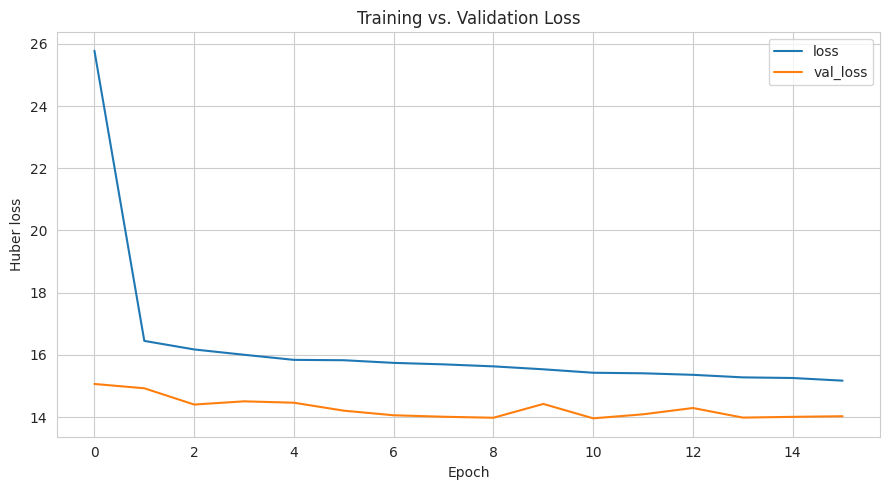

In [34]:
history_df = pd.DataFrame(history.history)

fig, ax = plt.subplots(figsize=(9, 5))
history_df[["loss", "val_loss"]].plot(ax=ax)
ax.set_title("Training vs. Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Huber loss")
plt.tight_layout()
plt.show()


## 6. Evaluate on the held-out test set

In [36]:
y_pred = score_model.predict(X_test_scaled).flatten()

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f} runs")
print(f"RMSE : {rmse:.2f} runs")
print(f"R^2  : {r2:.3f}")

476/476 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
MAE  : 14.45 runs
RMSE : 19.89 runs
R^2  : 0.532


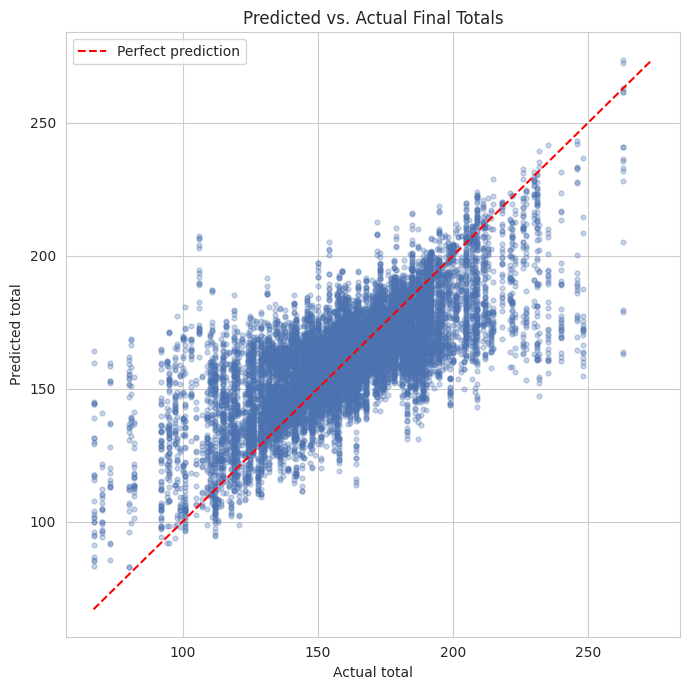

In [37]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, y_pred, alpha=0.3, s=12, color="#4C72B0")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, "r--", label="Perfect prediction")
ax.set_xlabel("Actual total")
ax.set_ylabel("Predicted total")
ax.set_title("Predicted vs. Actual Final Totals")
ax.legend()
plt.tight_layout()
plt.show()


## 7. Interactive live-score predictor

A small `ipywidgets` form that mirrors the in-game match state (venue, teams,
current batter/bowler, runs/wickets/overs so far) and returns the model's
projected final total.

In [38]:
import ipywidgets as widgets
from IPython.display import display, clear_output


def _dropdown(label, column):
    return widgets.Dropdown(
        options=list(encoders[column].classes_),
        description=label,
        style={"description_width": "initial"},
    )


venue_picker = _dropdown("Venue:", "venue")
batting_team_picker = _dropdown("Batting team:", "bat_team")
bowling_team_picker = _dropdown("Bowling team:", "bowl_team")
striker_picker = _dropdown("Striker:", "batsman")
bowler_picker = _dropdown("Bowler:", "bowler")

runs_input = widgets.BoundedIntText(value=0, min=0, max=350, description="Runs so far:",
                                     style={"description_width": "initial"})
wickets_input = widgets.BoundedIntText(value=0, min=0, max=10, description="Wickets down:",
                                        style={"description_width": "initial"})
overs_input = widgets.BoundedFloatText(value=0.0, min=0.0, max=20.0, step=0.1,
                                        description="Overs bowled:",
                                        style={"description_width": "initial"})
on_strike_input = widgets.BoundedIntText(value=0, min=0, max=1, description="Striker flag:",
                                          style={"description_width": "initial"})

run_button = widgets.Button(description="Predict final score", button_style="success")
result_box = widgets.Output()


def _predict_final_score(_):
    with result_box:
        clear_output()
        row = [
            encoders["bat_team"].transform([batting_team_picker.value])[0],
            encoders["bowl_team"].transform([bowling_team_picker.value])[0],
            encoders["venue"].transform([venue_picker.value])[0],
            runs_input.value,
            wickets_input.value,
            overs_input.value,
            on_strike_input.value,
            encoders["batsman"].transform([striker_picker.value])[0],
            encoders["bowler"].transform([bowler_picker.value])[0],
        ]
        scaled_row = feature_scaler.transform(np.array(row).reshape(1, -1))
        projected_total = score_model.predict(scaled_row, verbose=0)[0][0]
        print(f"Projected final total: {round(projected_total)} runs")


run_button.on_click(_predict_final_score)

display(widgets.VBox([
    venue_picker, batting_team_picker, bowling_team_picker,
    striker_picker, bowler_picker,
    runs_input, wickets_input, overs_input, on_strike_input,
    run_button, result_box,
]))
